In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [5]:
!ls -la experiments/exp4a_order_only_mentor_version/exp4a_order_only_mentor_ph1.sh

-rw------- 1 root root 8420 Apr  5 14:20 experiments/exp4a_order_only_mentor_version/exp4a_order_only_mentor_ph1.sh


In [3]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [4]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [6]:
!bash experiments/exp4a_order_only_mentor_version/exp4a_order_only_mentor_ph1.sh

Experiment 4a — Phase 1: Ordering Only (Mentor Version)
Embedding : X'_i = X_i + T_i (standard)
Attention : output = softmax(QK^T) · ΔV
  ΔV_i = V_i - V_{i-1}  (consecutive differences)
  ΔV_0 = 0               (first position)
  Ordering lives in VALUE SIDE of attention
  NO distance decay, NO Legendre, NO mean-field

Key fix vs Exp4: ordering is in attention, not embedding
No extra files needed — all in attn.py
Seed      : 2021 | Pred lengths: 96, 192 | Total runs: 2
Start: Sun Apr  5 02:21:00 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/2: exp4a_ph1_ETTh1_ordering_mentor_pred96_seed2021
pred_len=96 | seed=2021 | config=delta_V_in_attention
Start: Sun Apr  5 02:21:03 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, enc

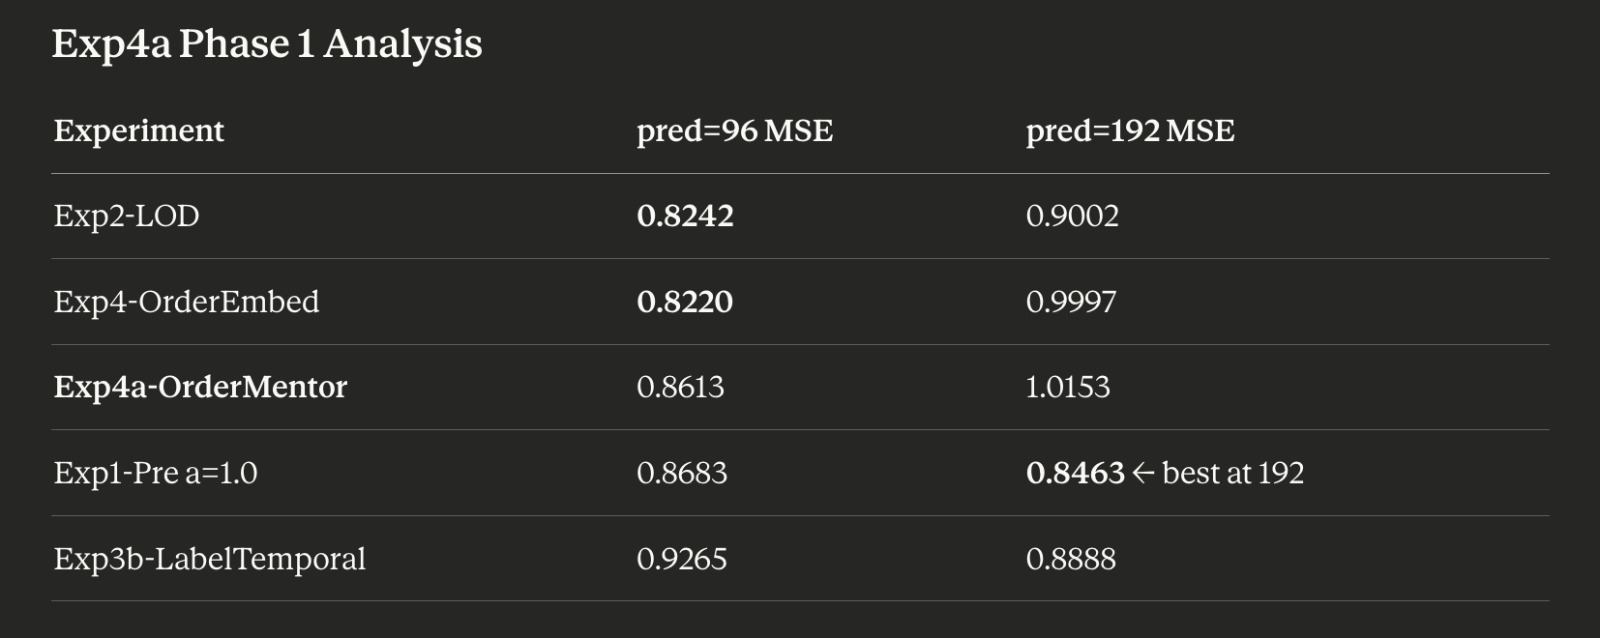

### What You Should Observe

The mentor's version is actually worse than the original Exp4 at both horizons.  
At pred=96, Exp4-OrderEmbed got **0.822** while Exp4a-OrderMentor gets **0.861**.  
At pred=192, Exp4-OrderEmbed got **0.9997** and Exp4a gets **1.015** — both bad but Exp4a is worse.

Exp4a is also worse than Exp1-Pre at both horizons, which means the value-side consecutive delta approach doesn't beat the simple pre-softmax distance decay.

**Why this happens:**  
Replacing **V entirely with (Vᵢ - Vᵢ₋₁)** removes absolute value information from the attention output. The model can no longer aggregate token content — it can only aggregate changes between consecutive tokens. This is too restrictive — for longer pred_lens where the model needs to recall content from many positions, stripping out absolute values collapses performance.

The train loss is also very low (**0.185 by epoch 4**) while val loss stays above **1.1** — same overfitting pattern as Exp2 and Exp4, the model memorises training deltas but can't generalise.

### Decision: Skip Phase 2

Applying the decision guide directly from the script:

- Exp4a worse than Exp4-OrderEmbed at both → attention placement may be correct concept but consecutive-only delta is too restrictive → stop

The result is clear enough with a single seed. Running Phase 2 would just confirm what is already obvious — this variant is worse than both Exp1-Pre and Exp4-OrderEmbed at every horizon. It doesn't beat anything we've already tried.

### Exp4a Conclusion to Document

The mentor's correct implementation of ordering — replacing attention values with consecutive differences  
**ΔVᵢ = Vᵢ - Vᵢ₋₁** inside the attention mechanism — performs worse than both the embedding-side ordering (Exp4) and the pre-softmax distance decay (Exp1-Pre).

At pred_len=96, MSE is **0.861 vs 0.868** for Exp1-Pre, and at pred_len=192, MSE is **1.015 vs 0.846**.

Replacing V entirely with consecutive deltas removes absolute positional content from the attention output, which is too restrictive for multi-step forecasting where the model needs to recall token content across many positions.

Phase 2 skipped — clear negative result at both horizons.

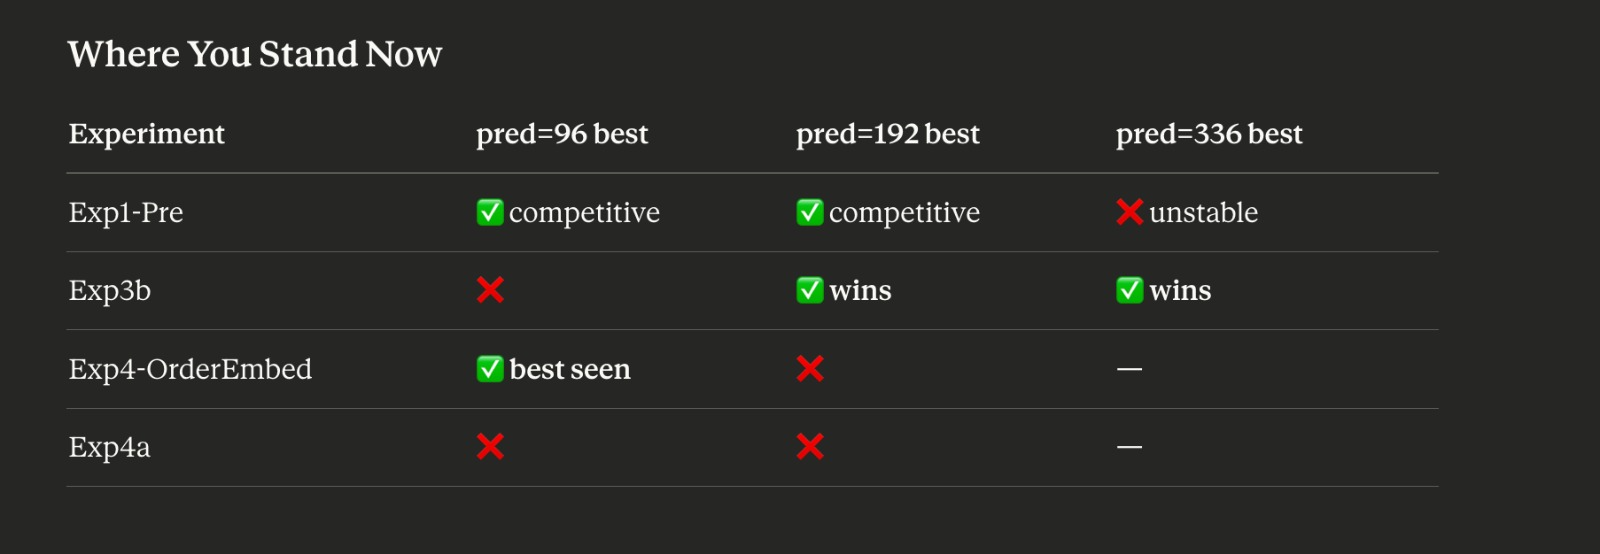